# Notebook 4 — Métriques & protocole d'évaluation

**Projet CEA-LIST × CentraleSupélec — Groupe 5**  
*Partie 4 sur 4 du benchmark de sélection de variables pour le clustering.*

---

## Objectif

Construire un **protocole d'évaluation rigoureux** pour comparer les cinq méthodes de sélection du notebook 3. Le protocole articule quatre étapes :

| Étape | Objectif | Outil principal |
|---|---|---|
| **1. Normalisation** | Rendre les scores comparables | Rangs normalisés dans $[0, 1]$ |
| **2. Benchmarks synthétiques** | Évaluer avec vérité terrain | 6 scénarios + ARI post-sélection |
| **3. Qualité hors clustering** | Mesurer indépendamment du clustering | Corrélation, t-SNE, LDA |
| **4. Stabilité et concordance** | Évaluer robustesse et redondance | Bootstrap Jaccard + $\tau$ de Kendall |

## Métriques utilisées

**Internes** (sans vérité terrain) : Silhouette, Davies-Bouldin, Calinski-Harabasz.  
**Externes** (avec vérité terrain) : ARI (*Adjusted Rand Index*), NMI (*Normalized Mutual Information*).  
**Spécifiques au projet** : longueur de règle $d'$, ratio de réduction $d'/d$, score CEA pénalisé.

## Données utilisées

Principalement le **jeu signal/bruit** du notebook 3 et ses variantes (6 scénarios, 4 formes non gaussiennes). Pour l'illustration finale sur données réelles, le dataset `glass` est utilisé (petit, propre, représentatif).

## Organisation

Chaque étape comporte : **principe → métrique formalisée → exécution → interprétation**. La dernière section synthétise les résultats en un tableau de bord agrégé.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso
from sklearn.datasets import make_blobs, load_wine
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.stats import kendalltau

np.random.seed(42)
print("Imports OK")

Imports OK


In [2]:
# ======================================================
# IMPLEMENTATIONS DES 5 METHODES (from scratch)
# ======================================================

def _build_S(X, k=5, t=None):
    n = X.shape[0]
    A = kneighbors_graph(X, n_neighbors=min(k, n-1),
                         mode='distance', include_self=False).toarray()
    if t is None:
        dq = A[A > 0]**2
        t = np.median(dq) if len(dq) > 0 else 1.0
    S = np.exp(-A**2 / t)
    S[A == 0] = 0
    S = (S + S.T) / 2
    np.fill_diagonal(S, 0)
    return S


def laplacian_score(X, k=5):
    n, d = X.shape
    S = _build_S(X, k)
    Dv = S.sum(1)
    L = np.diag(Dv) - S
    ones = np.ones(n)
    sc = np.zeros(d)
    for j in range(d):
        f = X[:, j].copy()
        ft = f - (f @ Dv) / (ones @ Dv) * ones
        sc[j] = (ft @ L @ ft) / (ft @ np.diag(Dv) @ ft + 1e-10)
    return sc  # bas = pertinent


def spec_score(X, K, k=5):
    n, d = X.shape
    S = _build_S(X, k)
    Dv = S.sum(1)
    Di = np.diag(1 / np.sqrt(Dv + 1e-10))
    Ln = Di @ (np.diag(Dv) - S) @ Di
    evals, evec = np.linalg.eigh(Ln)
    Vk = evec[:, np.argsort(evals)[1:min(K, n-1)+1]]
    sc = np.zeros(d)
    for j in range(d):
        fn = X[:, j] / (np.linalg.norm(X[:, j]) + 1e-10)
        sc[j] = 1.0 - np.sum((Vk.T @ fn)**2)
    return sc  # bas = pertinent


def sparse_kmeans(X, K, s=None, max_it=30, rs=42):
    n, d = X.shape
    s = s or np.sqrt(d) / 2
    w = np.ones(d) / np.sqrt(d)
    for _ in range(max_it):
        wo = w.copy()
        lbl = KMeans(K, n_init=5, random_state=rs).fit_predict(
            X * np.sqrt(np.maximum(w, 0)))
        gm = X.mean(0)
        a = np.zeros(d)
        for c in range(K):
            m = X[lbl == c]
            if len(m):
                a += len(m) * (m.mean(0) - gm)**2
        a /= n

        def st(av, delta):
            wr = np.maximum(av - delta, 0)
            nm = np.linalg.norm(wr)
            return wr / nm if nm > 1e-10 else wr

        lo, hi = 0.0, a.max()
        for _ in range(100):
            mid = (lo + hi) / 2
            if st(a, mid).sum() > s:
                lo = mid
            else:
                hi = mid
        w = st(a, hi)
        if np.max(np.abs(w - wo)) < 1e-4:
            break
    return lbl, w  # haut = pertinent


def mcfs_score(X, K, k=5, alpha=0.01):
    n, d = X.shape
    S = _build_S(X, k)
    Dv = S.sum(1)
    Di = np.diag(1 / np.sqrt(Dv + 1e-10))
    Ln = Di @ (np.diag(Dv) - S) @ Di
    evals, evec = np.linalg.eigh(Ln)
    Y = evec[:, np.argsort(evals)[1:min(K, n-1, d)+1]]
    W = np.column_stack([
        Lasso(alpha=alpha, max_iter=2000, fit_intercept=False).fit(X, Y[:, l]).coef_
        for l in range(Y.shape[1])
    ])
    return np.max(np.abs(W), axis=1)  # haut = pertinent


def fwkm(X, K, max_it=50, rs=42):
    n, d = X.shape
    w = np.ones(d) / d
    for _ in range(max_it):
        wo = w.copy()
        lbl = KMeans(K, n_init=5, random_state=rs).fit_predict(X * np.sqrt(w))
        Dj = np.zeros(d)
        for c in range(K):
            m = X[lbl == c]
            if len(m):
                Dj += np.sum((m - m.mean(0))**2, 0)
        Dj = np.maximum(Dj, 1e-10)
        wr = 1 / Dj
        w = wr / wr.sum()
        if np.max(np.abs(w - wo)) < 1e-5:
            break
    return lbl, w  # haut = pertinent


print("5 methodes chargees.")

5 methodes chargees.


---
## 1. Normalisation en rangs

### 1.1 Problème

Chaque méthode produit des scores sur des échelles fondamentalement différentes :

| Méthode | Échelle | Sens |
|---------|---------|------|
| Laplacian Score | $[0, 1]$ | **Bas** = pertinent |
| SPEC | $[0, 1]$ | **Bas** = pertinent |
| Sparse K-Means | $[0, 1]$, somme $\leq 1$ | **Haut** = pertinent |
| MCFS | $[0, +\infty)$ | **Haut** = pertinent |
| FWKM | $[0, 1]$, somme $= 1$ | **Haut** = pertinent |

Comparer directement ces valeurs n'a pas de sens : dire que MCFS attribue $0.42$ et LS $0.31$ à une même variable ne permet aucune conclusion.

### 1.2 Solution : rangs normalisés

L'information stable d'une méthode à l'autre est l'**ordre** qu'elle induit sur les variables. On convertit donc chaque score en rang normalisé dans $[0, 1]$ :

$$\text{rang\_norm}(j) = \frac{\text{rang}(j) - 1}{d - 1} \quad \in [0, 1]$$

où rang$(j) = 1$ désigne la variable la **plus pertinente** selon la méthode. Après cette transformation, toutes les méthodes sont sur la même échelle : $1$ = meilleure variable, $0$ = pire variable.

In [3]:
# ======================================================
# NORMALISATION EN RANGS
# ======================================================

def to_rank_norm(scores, higher_is_better):
    """
    Convertit des scores bruts en rangs normalises dans [0, 1].
    1 = variable la plus pertinente, 0 = la moins pertinente.
    """
    d = len(scores)
    if d == 1:
        return np.array([1.0])
    order = np.argsort(scores) if higher_is_better else np.argsort(-scores)
    rank_norm = np.empty(d)
    for rank, idx in enumerate(order):
        rank_norm[idx] = rank / (d - 1)
    return rank_norm


def run_all_methods(X, K, k_neighbors=5):
    """
    Applique les 5 methodes et retourne un dict de rangs normalises.
    Toutes les valeurs dans [0, 1] — 1 = variable la plus pertinente.
    """
    _, sk_w = sparse_kmeans(X, K)
    _, fw_w = fwkm(X, K)
    return {
        'LS':   to_rank_norm(laplacian_score(X, k_neighbors), higher_is_better=False),
        'SPEC': to_rank_norm(spec_score(X, K, k_neighbors),   higher_is_better=False),
        'SKM':  to_rank_norm(sk_w,                            higher_is_better=True),
        'MCFS': to_rank_norm(mcfs_score(X, K, k_neighbors),   higher_is_better=True),
        'FWKM': to_rank_norm(fw_w,                            higher_is_better=True),
    }


METHODS = ['LS', 'SPEC', 'SKM', 'MCFS', 'FWKM']
COLORS  = {'LS': '#534AB7', 'SPEC': '#0F6E56', 'SKM': '#993C1D',
           'MCFS': '#993556', 'FWKM': '#3B8BD4'}

print("Normalisation en rangs prete.")

Normalisation en rangs prete.


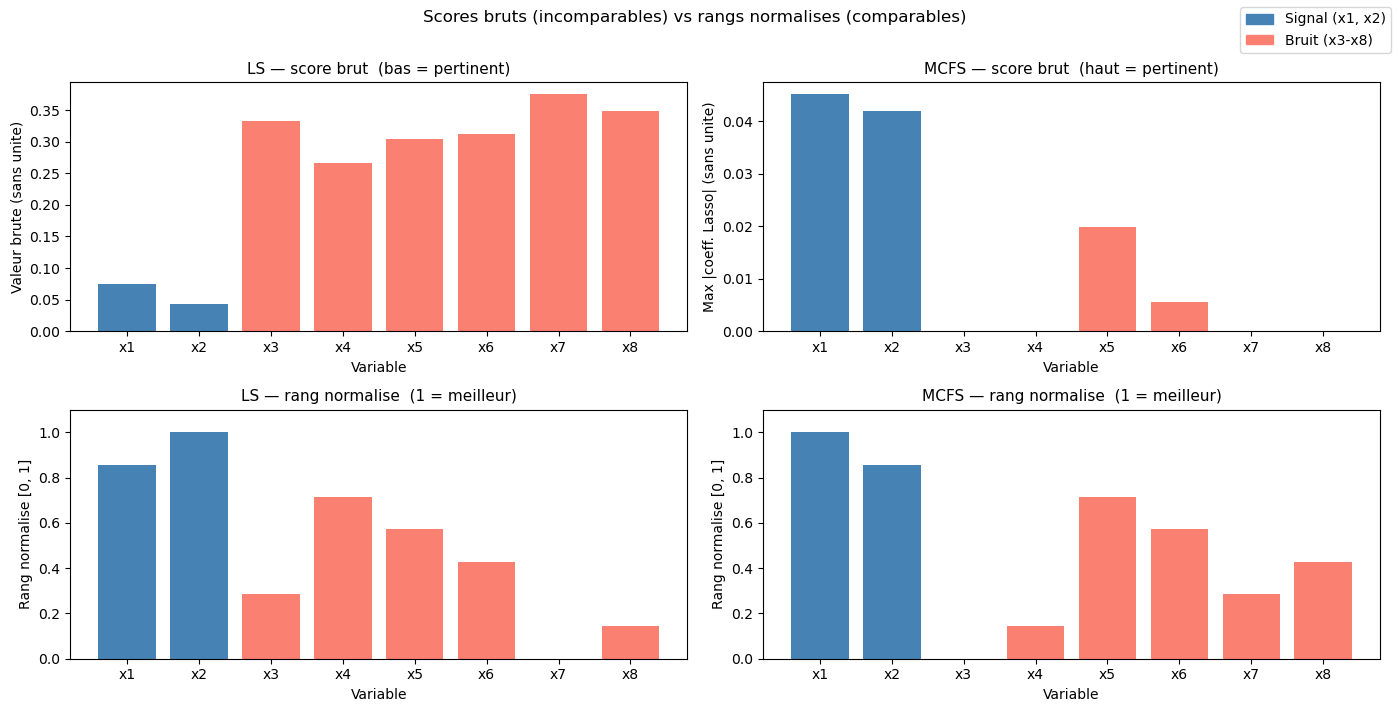

In [4]:
# ======================================================
# ILLUSTRATION : scores bruts vs rangs normalises
# ======================================================

np.random.seed(42)
X_il, y_il = make_blobs(n_samples=200, centers=3, n_features=2,
                         cluster_std=1.2, random_state=42)
X_il = StandardScaler().fit_transform(
    np.hstack([X_il, np.random.randn(200, 6)]))
d_il = X_il.shape[1]
feat_il = [f'x{i+1}' for i in range(d_il)]
bar_c = ['steelblue' if i < 2 else 'salmon' for i in range(d_il)]

raw_ls   = laplacian_score(X_il)
raw_mcfs = mcfs_score(X_il, 3)
ranks_il = run_all_methods(X_il, 3)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

axes[0, 0].bar(feat_il, raw_ls, color=bar_c)
axes[0, 0].set_title('LS — score brut  (bas = pertinent)', fontsize=11)
axes[0, 0].set_ylabel('Valeur brute (sans unite)')

axes[0, 1].bar(feat_il, raw_mcfs, color=bar_c)
axes[0, 1].set_title('MCFS — score brut  (haut = pertinent)', fontsize=11)
axes[0, 1].set_ylabel('Max |coeff. Lasso| (sans unite)')

axes[1, 0].bar(feat_il, ranks_il['LS'], color=bar_c)
axes[1, 0].set_ylim(0, 1.1)
axes[1, 0].set_title('LS — rang normalise  (1 = meilleur)', fontsize=11)
axes[1, 0].set_ylabel('Rang normalise [0, 1]')

axes[1, 1].bar(feat_il, ranks_il['MCFS'], color=bar_c)
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].set_title('MCFS — rang normalise  (1 = meilleur)', fontsize=11)
axes[1, 1].set_ylabel('Rang normalise [0, 1]')

for ax in axes.flat:
    ax.set_xlabel('Variable')

legend_els = [mpatches.Patch(color='steelblue', label='Signal (x1, x2)'),
              mpatches.Patch(color='salmon',     label='Bruit (x3-x8)')]
fig.legend(handles=legend_els, loc='upper right', fontsize=10)
plt.suptitle('Scores bruts (incomparables) vs rangs normalises (comparables)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/raw_vs_rank_norm.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Benchmarks synthétiques contrôlés

### 2.1 Principe

Sur des données réelles, on ne sait pas quelles variables sont pertinentes. Un dataset synthétique règle ce problème : on **choisit** quelles variables portent le signal, puis on mesure si les méthodes les retrouvent.

La structure commune est :
- $n_{\text{signal}} = 2$ **variables signal** : générées par `make_blobs`, elles portent la structure de cluster
- $n_{\text{bruit}}$ **variables bruit** : tirées indépendamment de $\mathcal{N}(0,1)$, sans lien avec les clusters

### 2.2 Taxonomie des scénarios

On fait varier trois axes indépendants, chacun correspondant à une difficulté réelle :

```
 AXE 1 — Separation des clusters (cluster_std)
 ┌─────────────────────────────────────────────────────────────────┐
 │  std = 0.8          std = 1.5           std = 2.5              │
 │  clusters serres  →  standard      →  clusters etales         │
 │  [FACILE]                               [DIFFICILE]            │
 └─────────────────────────────────────────────────────────────────┘

 AXE 2 — Rapport signal/bruit (n_bruit)
 ┌─────────────────────────────────────────────────────────────────┐
 │  2 vars bruit       8 vars bruit      20 vars bruit            │
 │  signal domine  →   equilibre    →   bruit domine              │
 │  [FACILE]                               [DIFFICILE]            │
 └─────────────────────────────────────────────────────────────────┘

 AXE 3 — Complexite de la structure (k)
 ┌─────────────────────────────────────────────────────────────────┐
 │  k = 2              k = 3              k = 5                   │
 │  binaire        →   standard      →   multi-clusters           │
 │  [FACILE]                               [DIFFICILE]            │
 └─────────────────────────────────────────────────────────────────┘
```

Six scénarios représentatifs sont retenus :

| Scénario | `std` | `n_bruit` | `k` 
|----------|:-----:|:---------:|:---|
| S1 — Référence facile     | 0.8 |  2 | 3 |
| S2 — Standard             | 1.5 |  8 | 3 |
| S3 — Clusters étalés      | 2.5 |  8 | 3 |
| S4 — Haute dim. bruit     | 1.5 | 20 | 3 |
| S5 — Plus de clusters     | 1.5 |  8 | 5 |
| S6 — Cas extrême          | 2.5 | 20 | 2 |

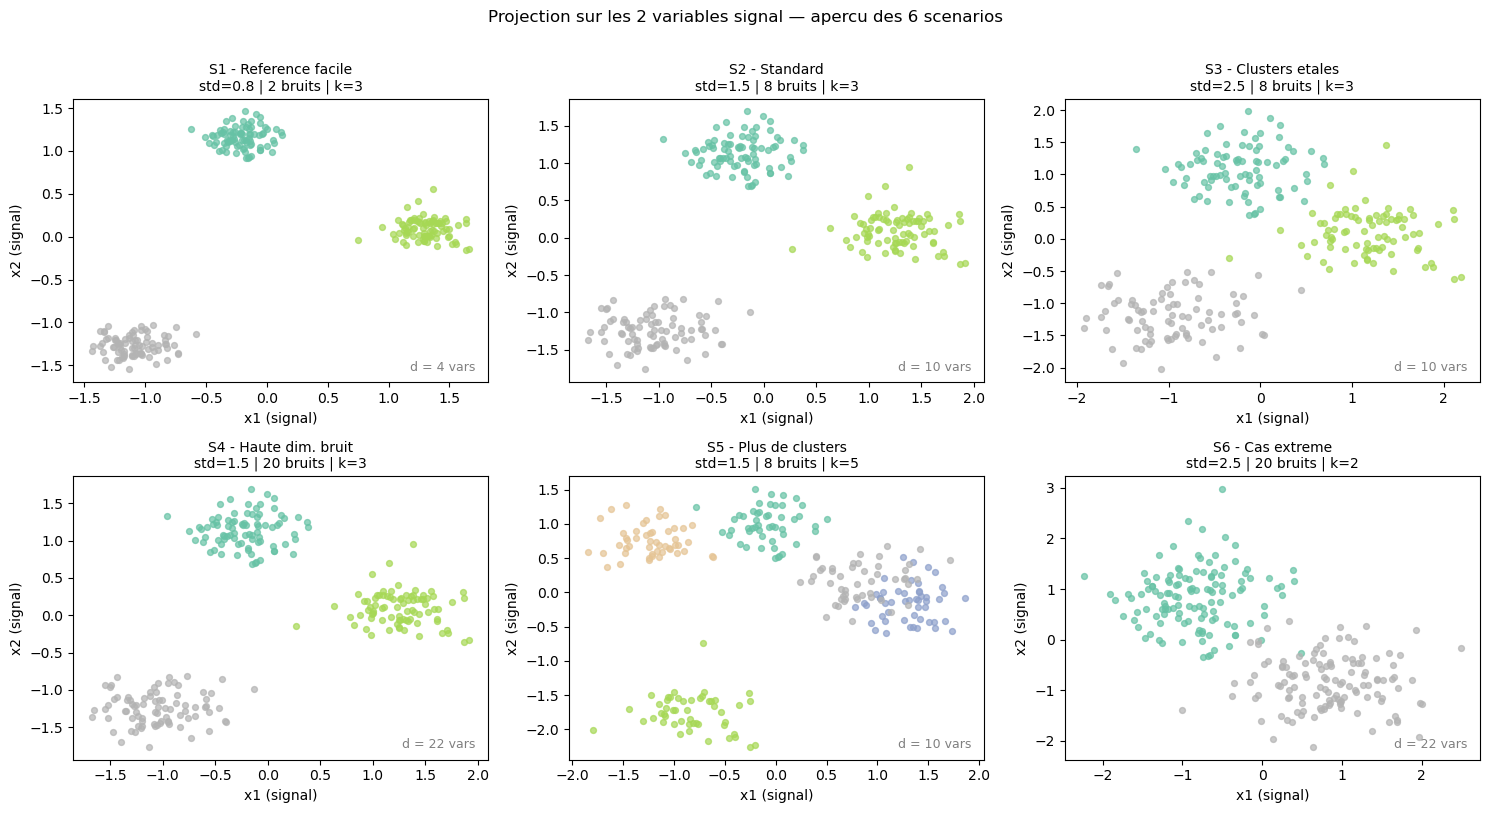

In [5]:
# ======================================================
# VISUALISATION DES 6 SCENARIOS
# ======================================================

SCENARIOS = [
    # (std, n_noise, k, label)
    (0.8,  2, 3, 'S1 - Reference facile\nstd=0.8 | 2 bruits | k=3'),
    (1.5,  8, 3, 'S2 - Standard\nstd=1.5 | 8 bruits | k=3'),
    (2.5,  8, 3, 'S3 - Clusters etales\nstd=2.5 | 8 bruits | k=3'),
    (1.5, 20, 3, 'S4 - Haute dim. bruit\nstd=1.5 | 20 bruits | k=3'),
    (1.5,  8, 5, 'S5 - Plus de clusters\nstd=1.5 | 8 bruits | k=5'),
    (2.5, 20, 2, 'S6 - Cas extreme\nstd=2.5 | 20 bruits | k=2'),
]


def make_synthetic(std, n_noise, k, n_signal=2, n=250, seed=42):
    Xs, y = make_blobs(n_samples=n, centers=k, n_features=n_signal,
                        cluster_std=std, random_state=seed)
    Xn = np.random.RandomState(seed).randn(n, n_noise)
    X = StandardScaler().fit_transform(np.hstack([Xs, Xn]))
    return X, y


cmap = plt.cm.Set2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (std, n_noise, k, label) in zip(axes.flat, SCENARIOS):
    X, y = make_synthetic(std, n_noise, k)
    for c in range(k):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=18, alpha=0.7,
                   color=cmap(c / max(k-1, 1)))
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('x1 (signal)')
    ax.set_ylabel('x2 (signal)')
    ax.text(0.97, 0.04, f'd = {2 + n_noise} vars', transform=ax.transAxes,
            ha='right', fontsize=9, color='gray')

plt.suptitle('Projection sur les 2 variables signal — apercu des 6 scenarios',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/scenarios_overview.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Métrique d'évaluation : l'ARI

Pour mesurer si une méthode de sélection a bien fait son travail, on applique la procédure suivante :

1. La méthode sélectionne les $k' = n_{\text{signal}}$ meilleures variables (ici $k' = 2$)
2. On applique K-Means sur ce sous-ensemble
3. On compare les clusters obtenus aux vrais labels via l'**Adjusted Rand Index (ARI)**

#### Qu'est-ce que l'ARI ?

L'ARI mesure la concordance entre deux partitions en s'appuyant sur le comptage des **paires de points** :

| | Même cluster (prédit) | Clusters différents (prédit) |
|---|---|---|
| **Même cluster (réel)** | TP — paire concordante | FN |
| **Clusters différents (réel)** | FP | TN — paire concordante |

L'index de Rand brut $RI = (TP + TN) / \binom{n}{2}$ est **ajusté pour le hasard** :

$$\text{ARI} = \frac{RI - \mathbb{E}[RI]}{\max(RI) - \mathbb{E}[RI]} \in [-1, 1]$$

| Valeur ARI | Interprétation |
|:----------:|----------------|
| $1$ | Clustering parfait |
| $\approx 0$ | Résultat aléatoire |
| $< 0$ | Pire qu'un clustering aléatoire |

L'ajustement est crucial : sans lui, mettre tous les points dans un seul cluster donnerait un RI artificiellement élevé.

In [6]:
# ======================================================
# ARI POST-SELECTION SUR LES 6 SCENARIOS
# ======================================================

def ari_after_selection(X, y_true, rank_norm, k_prime, K):
    """ARI d'un KMeans sur les k_prime meilleures variables."""
    top = np.argsort(-rank_norm)[:k_prime]
    lbl = KMeans(n_clusters=K, n_init=10, random_state=42).fit_predict(X[:, top])
    return adjusted_rand_score(y_true, lbl)


N_SIGNAL = 2
ari_rows = []

print(f"{'Scenario':<45} {'LS':>6} {'SPEC':>6} {'SKM':>6} {'MCFS':>6} {'FWKM':>6}")
print("-" * 75)

for std, n_noise, k, label in SCENARIOS:
    X, y = make_synthetic(std, n_noise, k)
    ranks = run_all_methods(X, K=k)
    row = {'scenario': label.replace('\n', ' ')}
    for m in METHODS:
        row[m] = ari_after_selection(X, y, ranks[m], N_SIGNAL, k)
    ari_rows.append(row)
    vals = '  '.join(f"{row[m]:>6.3f}" for m in METHODS)
    print(f"{label.replace(chr(10), ' ')[:43]:<45} {vals}")

df_ari = pd.DataFrame(ari_rows)
print()
print("ARI moyen par methode :")
for m in METHODS:
    print(f"  {m:<6} : {df_ari[m].mean():.3f}")

Scenario                                          LS   SPEC    SKM   MCFS   FWKM
---------------------------------------------------------------------------
S1 - Reference facile std=0.8 | 2 bruits |     1.000   0.428   0.428   0.428   1.000


S2 - Standard std=1.5 | 8 bruits | k=3         1.000   1.000   1.000   1.000   1.000


S3 - Clusters etales std=2.5 | 8 bruits | k    0.976   0.976   0.976   0.409   0.976


S4 - Haute dim. bruit std=1.5 | 20 bruits |    1.000   1.000   1.000   1.000   1.000


S5 - Plus de clusters std=1.5 | 8 bruits |     0.847   0.847   0.847   0.847   0.847


S6 - Cas extreme std=2.5 | 20 bruits | k=2     0.906   0.906   0.906   0.906   0.906

ARI moyen par methode :
  LS     : 0.955
  SPEC   : 0.859
  SKM    : 0.859
  MCFS   : 0.765
  FWKM   : 0.955


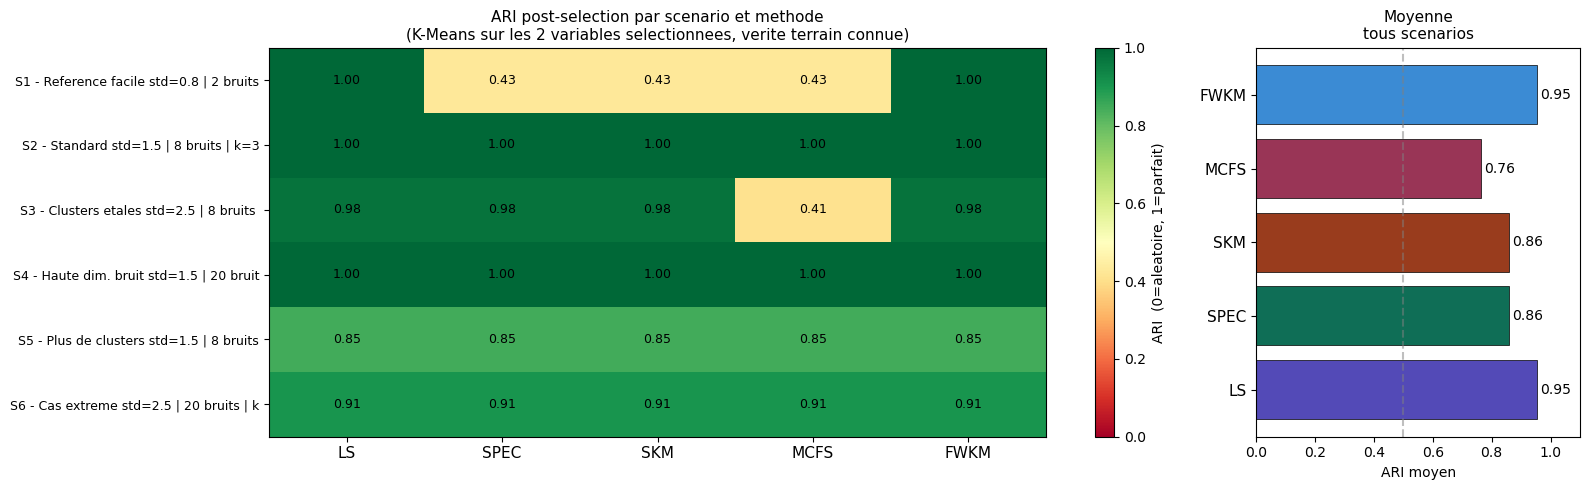

In [7]:
# ======================================================
# VISUALISATION — Heatmap ARI
# ======================================================

short_labels = [label.replace('\n', ' ')[:40]
                for _, _, _, label in SCENARIOS]
pivot = df_ari.set_index('scenario')[METHODS]
pivot.index = short_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                          gridspec_kw={'width_ratios': [3, 1]})

# Heatmap
im = axes[0].imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(METHODS)))
axes[0].set_xticklabels(METHODS, fontsize=11)
axes[0].set_yticks(range(len(short_labels)))
axes[0].set_yticklabels(short_labels, fontsize=9)
axes[0].set_title(
    'ARI post-selection par scenario et methode\n'
    '(K-Means sur les 2 variables selectionnees, verite terrain connue)',
    fontsize=11)
plt.colorbar(im, ax=axes[0], label='ARI  (0=aleatoire, 1=parfait)')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.iloc[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=9,
                     color='white' if v < 0.3 else 'black')

# ARI moyen
means = pivot.mean(axis=0)
bars = axes[1].barh(range(len(METHODS)),
                     [means[m] for m in METHODS],
                     color=[COLORS[m] for m in METHODS],
                     edgecolor='k', linewidth=0.5)
axes[1].set_yticks(range(len(METHODS)))
axes[1].set_yticklabels(METHODS, fontsize=11)
axes[1].set_xlim(0, 1.1)
axes[1].set_xlabel('ARI moyen')
axes[1].set_title('Moyenne\ntous scenarios', fontsize=11)
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
for bar, m in zip(bars, METHODS):
    axes[1].text(bar.get_width() + 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{means[m]:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('figures/ari_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2bis. Formes de clusters non gaussiennes

Les scénarios précédents utilisent `make_blobs` — des clusters gaussiens isotropes,
le cas le plus favorable à K-Means. On teste ici 4 formes structurellement différentes
pour voir si les méthodes de sélection restent efficaces quand la géométrie est plus complexe.

| Forme | Structure | K-Means adapté ? |
|-------|-----------|:-----------------:|
| Gaussiens (référence) | Clusters sphériques | Oui |
| Lunes | Clusters en croissants non convexes | Non |
| Anneaux | Clusters concentriques | Non |
| Allongés | Clusters elliptiques orientés | Partiel |

**Objectif** : comparer les méthodes **entre elles** indépendamment du clustering.
On regarde directement si le sous-ensemble sélectionné par chaque méthode
permet de voir visuellement les vrais groupes (projection 2D des variables signal).

In [8]:
# ======================================================
# FORMES NON GAUSSIENNES — génération
# ======================================================
from sklearn.datasets import make_circles, make_moons

N_NOISE_SHAPE = 8   # variables bruit ajoutées dans tous les cas
N_PTS = 300

def add_noise_and_scale(X_signal, y, n_noise=N_NOISE_SHAPE, seed=42):
    """Ajoute n_noise variables N(0,1) et standardise."""
    rng = np.random.RandomState(seed)
    Xn  = rng.randn(len(X_signal), n_noise)
    X   = np.hstack([X_signal, Xn])
    return StandardScaler().fit_transform(X), y

# Gaussiens (référence)
Xg_raw, yg = make_blobs(n_samples=N_PTS, centers=3, n_features=2,
                         cluster_std=1.0, random_state=42)
Xg, yg = add_noise_and_scale(Xg_raw, yg)

# Lunes
Xm_raw, ym = make_moons(n_samples=N_PTS, noise=0.1, random_state=42)
Xm, ym = add_noise_and_scale(Xm_raw, ym)

# Anneaux
Xc_raw, yc = make_circles(n_samples=N_PTS, noise=0.05, factor=0.4, random_state=42)
Xc, yc = add_noise_and_scale(Xc_raw, yc)

# Allongés (blobs avec covariance)
rng = np.random.RandomState(42)
centers = [[-3, 0], [3, 0], [0, 4]]
T = np.array([[2, 0.8], [0.8, 0.3]])   # transformation linéaire
Xe_parts, ye_parts = [], []
for c_idx, center in enumerate(centers):
    pts = rng.randn(N_PTS // 3, 2) @ T + center
    Xe_parts.append(pts)
    ye_parts.append(np.full(N_PTS // 3, c_idx))
Xe_raw = np.vstack(Xe_parts)
ye     = np.concatenate(ye_parts)
Xe, ye = add_noise_and_scale(Xe_raw, ye)

SHAPES = [
    (Xg, yg, 3, 'Gaussiens (référence)', '#4a90d9'),
    (Xm, ym, 2, 'Lunes',                 '#e67e22'),
    (Xc, yc, 2, 'Anneaux',               '#27ae60'),
    (Xe, ye, 3, 'Allongés',              '#8e44ad'),
]

print('Formes generees :')
for X, y, k, name, _ in SHAPES:
    print(f'  {name:<22} : {X.shape[0]} pts, {X.shape[1]} vars ({N_NOISE_SHAPE} bruit), k={k}')


Formes generees :
  Gaussiens (référence)  : 300 pts, 10 vars (8 bruit), k=3
  Lunes                  : 300 pts, 10 vars (8 bruit), k=2
  Anneaux                : 300 pts, 10 vars (8 bruit), k=2
  Allongés               : 300 pts, 10 vars (8 bruit), k=3


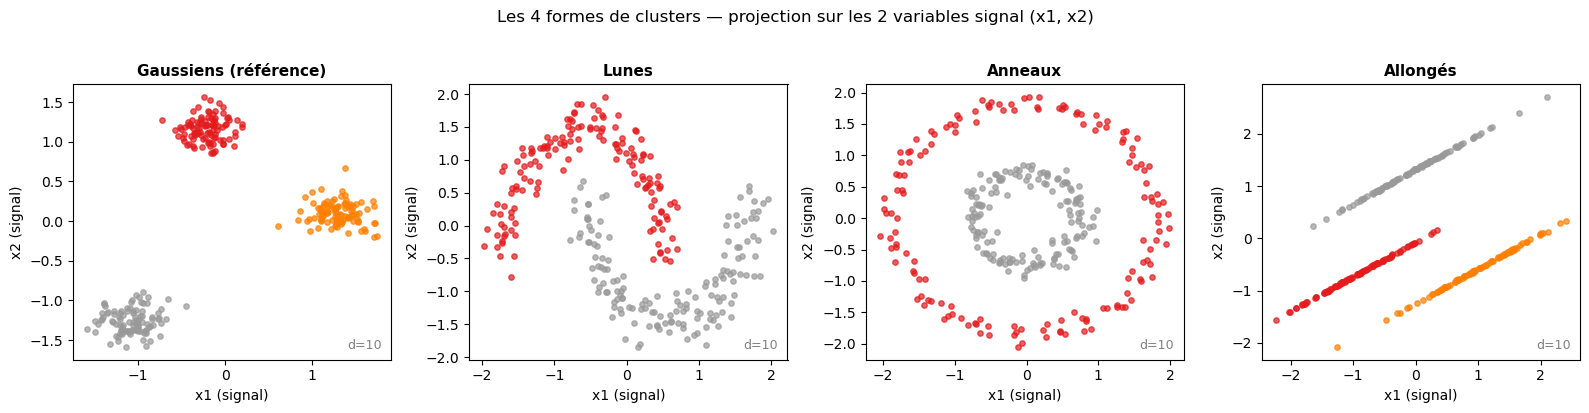

In [9]:
# ======================================================
# VISUALISATION — les 4 formes sur variables signal
# ======================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cmap_shapes = plt.cm.Set1

for ax, (X, y, k, name, col) in zip(axes, SHAPES):
    for c in range(k):
        mask = y == c
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7,
                   color=cmap_shapes(c / max(k-1, 1)))
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('x1 (signal)')
    ax.set_ylabel('x2 (signal)')
    ax.text(0.97, 0.04, f'd={X.shape[1]}', transform=ax.transAxes,
            ha='right', fontsize=9, color='gray')

plt.suptitle('Les 4 formes de clusters — projection sur les 2 variables signal (x1, x2)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/shapes_signal.png', dpi=120, bbox_inches='tight')
plt.show()


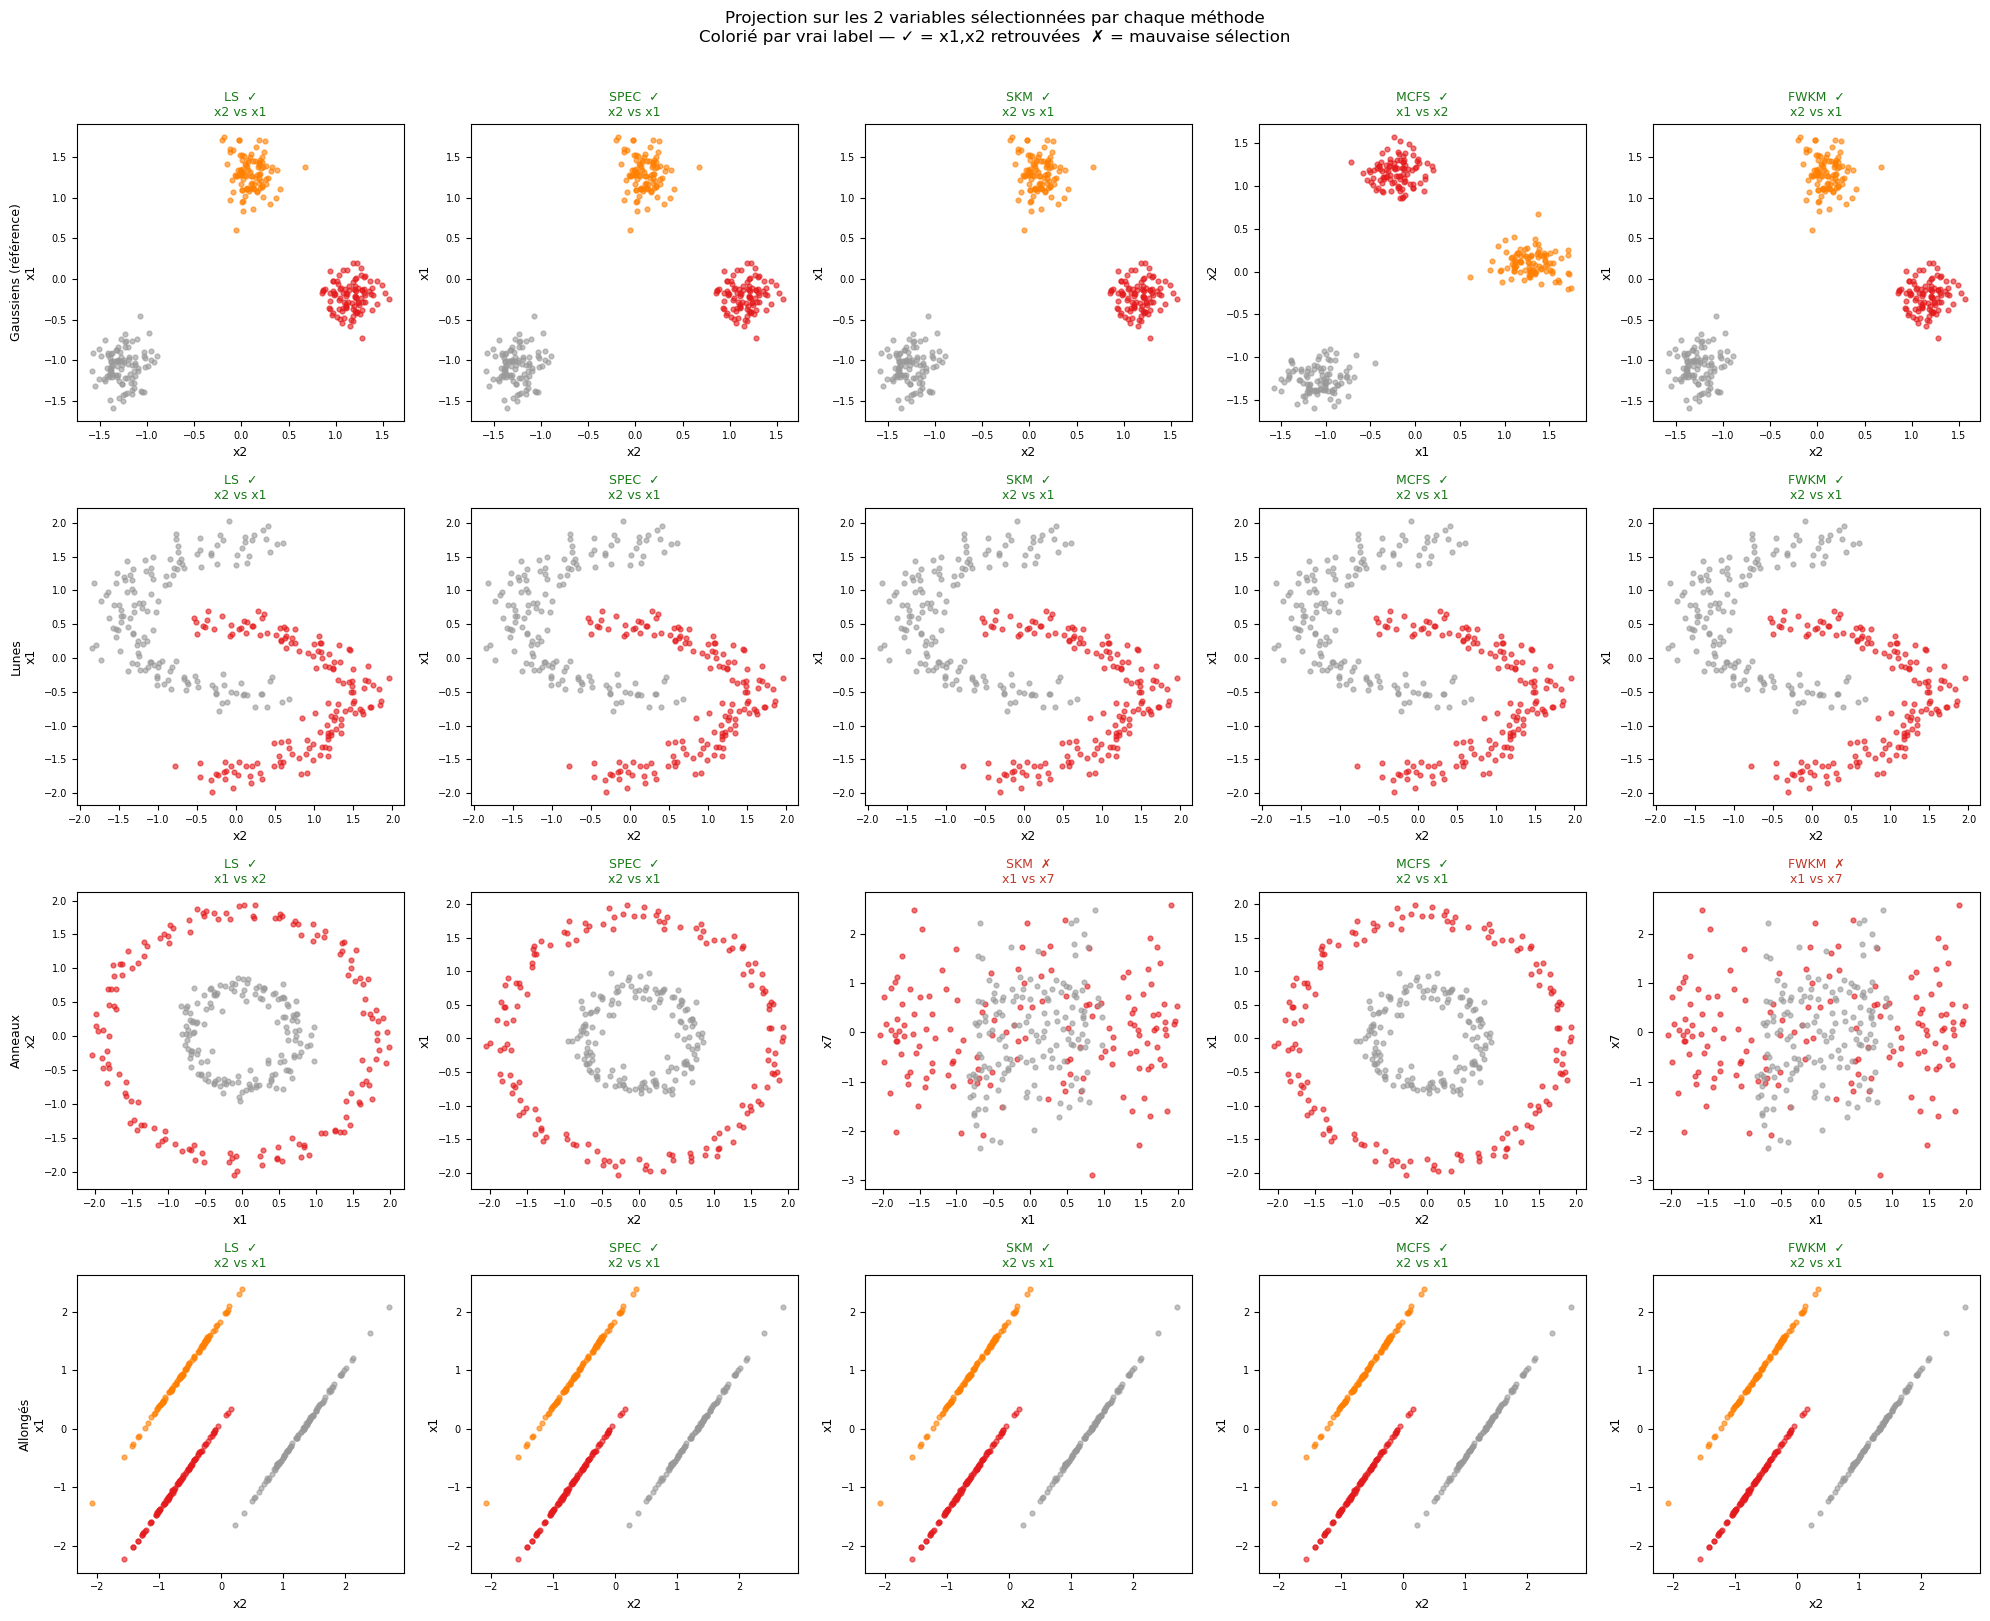

In [10]:
# ======================================================
# MÉTHODES DE SÉLECTION SUR LES 4 FORMES
# Visualisation : top-2 variables sélectionnées par chaque méthode
# ======================================================

fig, axes = plt.subplots(len(SHAPES), len(METHODS),
                          figsize=(4 * len(METHODS), 4 * len(SHAPES)))

for row, (X, y, k, shape_name, _) in enumerate(SHAPES):
    ranks = run_all_methods(X, K=k)
    for col, m in enumerate(METHODS):
        ax = axes[row, col]
        top2 = np.argsort(-ranks[m])[:2]
        correct = set(top2) == {0, 1}    # a-t-on retrouvé x1 et x2 ?

        for c in range(k):
            mask = y == c
            ax.scatter(X[mask, top2[0]], X[mask, top2[1]],
                       s=12, alpha=0.6, color=cmap_shapes(c / max(k-1, 1)))

        feat_names_top = [f'x{top2[0]+1}', f'x{top2[1]+1}']
        ax.set_xlabel(feat_names_top[0], fontsize=9)
        ax.set_ylabel(feat_names_top[1], fontsize=9)

        # Couleur du titre : vert si on a retrouvé x1,x2 / rouge sinon
        title_color = '#1a7a1a' if correct else '#c0392b'
        tick = '✓' if correct else '✗'
        ax.set_title(f'{m}  {tick}\n{feat_names_top[0]} vs {feat_names_top[1]}',
                     fontsize=9, color=title_color)
        ax.tick_params(labelsize=7)

        if col == 0:
            ax.set_ylabel(f'{shape_name}\n{feat_names_top[1]}', fontsize=9)

plt.suptitle(
    'Projection sur les 2 variables sélectionnées par chaque méthode\n'
    'Colorié par vrai label — ✓ = x1,x2 retrouvées  ✗ = mauvaise sélection',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/shapes_selection_projection.png', dpi=120, bbox_inches='tight')
plt.show()


In [11]:
# ======================================================
# ARI : méthode sélection × algo clustering × forme
# ======================================================
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

CLUSTERING_ALGOS = ['K-Means', 'Ward', 'DBSCAN']


def cluster_and_ari(X_sub, y_true, k, algo):
    """Applique algo sur X_sub et retourne l'ARI."""
    if algo == 'K-Means':
        lbl = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_sub)
    elif algo == 'Ward':
        lbl = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_sub)
    elif algo == 'DBSCAN':
        # eps estimé par le coude des k-distances
        nbrs = NearestNeighbors(n_neighbors=5).fit(X_sub)
        dists, _ = nbrs.kneighbors(X_sub)
        eps = np.percentile(np.sort(dists[:, -1]), 90)
        lbl = DBSCAN(eps=eps, min_samples=5).fit_predict(X_sub)
        # Points bruit (label=-1) ignorés pour ARI
        mask = lbl >= 0
        if mask.sum() < 10 or len(np.unique(lbl[mask])) < 2:
            return np.nan
        return adjusted_rand_score(y_true[mask], lbl[mask])
    return adjusted_rand_score(y_true, lbl)


shape_ari_rows = []
for X, y, k, shape_name, _ in SHAPES:
    ranks = run_all_methods(X, K=k)
    # Baseline : toutes les variables
    for algo in CLUSTERING_ALGOS:
        ari_base = cluster_and_ari(X, y, k, algo)
        shape_ari_rows.append({
            'forme': shape_name, 'selection': 'Baseline (toutes)',
            'clustering': algo, 'ARI': ari_base
        })
    # Après sélection
    for m in METHODS:
        top2 = np.argsort(-ranks[m])[:2]
        X_sel = X[:, top2]
        for algo in CLUSTERING_ALGOS:
            ari = cluster_and_ari(X_sel, y, k, algo)
            shape_ari_rows.append({
                'forme': shape_name, 'selection': m,
                'clustering': algo, 'ARI': ari
            })

df_shape_ari = pd.DataFrame(shape_ari_rows)
print('ARI par forme / méthode sélection / algo clustering :')
print(df_shape_ari.pivot_table(
    index=['forme', 'selection'], columns='clustering',
    values='ARI').round(3).to_string())


ARI par forme / méthode sélection / algo clustering :
clustering                               DBSCAN  K-Means   Ward
forme                 selection                                
Allongés              Baseline (toutes)     NaN    0.751  0.547
                      FWKM                0.890    0.828  0.990
                      LS                  0.890    0.828  0.990
                      MCFS                0.890    0.828  0.990
                      SKM                 0.890    0.828  0.990
                      SPEC                0.890    0.828  0.990
Anneaux               Baseline (toutes)     NaN   -0.001  0.007
                      FWKM                0.003   -0.003  0.004
                      LS                  0.574   -0.003 -0.002
                      MCFS                0.574   -0.003 -0.002
                      SKM                 0.003   -0.003  0.004
                      SPEC                0.574   -0.003 -0.002
Gaussiens (référence) Baseline (toutes)     NaN   

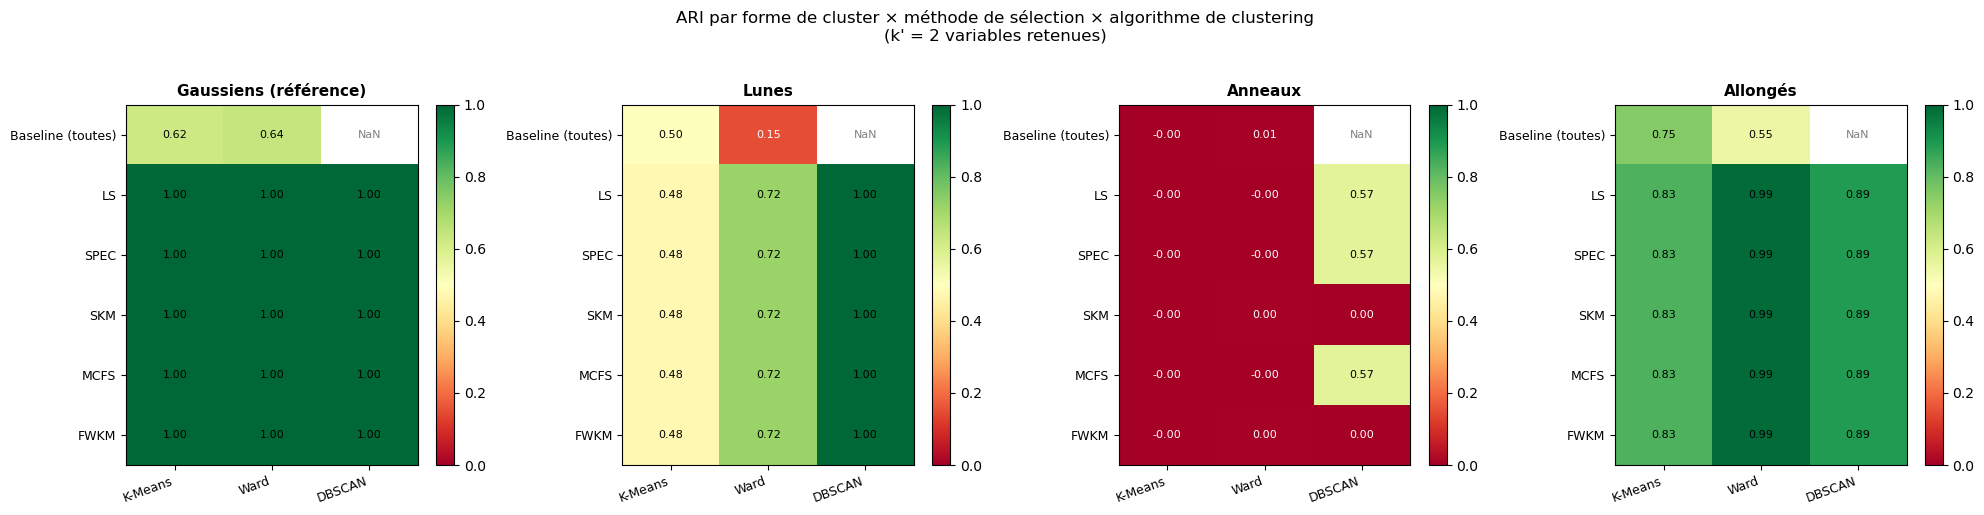

In [12]:
# ======================================================
# VISUALISATION — heatmap ARI formes × sélection × clustering
# ======================================================

shape_names = [name for _, _, _, name, _ in SHAPES]
sel_order   = ['Baseline (toutes)'] + METHODS

fig, axes = plt.subplots(1, len(shape_names),
                          figsize=(5 * len(shape_names), 5))

for ax, shape_name in zip(axes, shape_names):
    sub = df_shape_ari[df_shape_ari['forme'] == shape_name]
    piv = sub.pivot_table(index='selection', columns='clustering',
                          values='ARI').reindex(index=sel_order,
                                                columns=CLUSTERING_ALGOS)
    im = ax.imshow(piv.values.astype(float), cmap='RdYlGn',
                   vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(CLUSTERING_ALGOS)))
    ax.set_xticklabels(CLUSTERING_ALGOS, fontsize=9, rotation=20, ha='right')
    ax.set_yticks(range(len(sel_order)))
    ax.set_yticklabels(sel_order, fontsize=9)
    ax.set_title(shape_name, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax)
    for i in range(len(sel_order)):
        for j in range(len(CLUSTERING_ALGOS)):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if v < 0.35 else 'black')
            else:
                ax.text(j, i, 'NaN', ha='center', va='center',
                        fontsize=8, color='gray')

plt.suptitle(
    'ARI par forme de cluster × méthode de sélection × algorithme de clustering\n'
    '(k\' = 2 variables retenues)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/shapes_ari_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 2ter. Qualité du filtre indépendamment du clustering

Les évaluations précédentes mesurent la qualité *après* avoir appliqué un algorithme de clustering.
Mais la sélection de variables est une étape **distincte** — on peut juger sa qualité
sans faire de clustering.

Deux métriques complémentaires :

| Outil | Ce qu'il mesure | Méthode détaillée |
|-------|-----------------|-------------------|
| **Corrélation signal** | Les variables sélectionnées sont-elles corrélées aux vraies variables ? | On calcule la matrice de **corrélation de Pearson** $r(x_i, x_j) = \frac{\sum_k (x_i^{(k)}-\bar{x}_i)(x_j^{(k)}-\bar{x}_j)}{\sigma_{x_i}\,\sigma_{x_j}}$ entre toutes les variables. Pour chaque méthode, on extrait le top-$k'$ variables sélectionnées et on mesure leur corrélation absolue $|r|$ avec chacune des vraies variables signal ($x_1$, $x_2$). Un score proche de 1 indique que la méthode a bien retrouvé les variables porteuses de la structure. |
| **t-SNE** | Les vrais groupes sont-ils visuellement séparables dans l'espace réduit ? | On applique **t-SNE** (t-distributed Stochastic Neighbor Embedding) sur le sous-ensemble de variables sélectionnées. t-SNE minimise la divergence KL entre une distribution de similarités dans l'espace original (noyau gaussien) et une distribution Student-$t$ dans l'espace 2D : $\text{KL}(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$. On colorie ensuite les points selon leurs vrais labels et on évalue visuellement si les clusters sont bien séparés dans la projection 2D. |
| **Score LDA** | Les classes sont-elles linéairement séparables dans l'espace réduit ? | **LDA** (Linear Discriminant Analysis) cherche la projection $w$ qui maximise le ratio $\frac{w^\top S_B\, w}{w^\top S_W\, w}$, où $S_B$ est la matrice de dispersion inter-classes et $S_W$ la matrice de dispersion intra-classes. On entraîne un classifieur LDA sur l'espace réduit (variables sélectionnées) avec les vrais labels, puis on mesure le score de classification par validation croisée. Un score élevé indique que les variables sélectionnées permettent une séparation linéaire des groupes. |


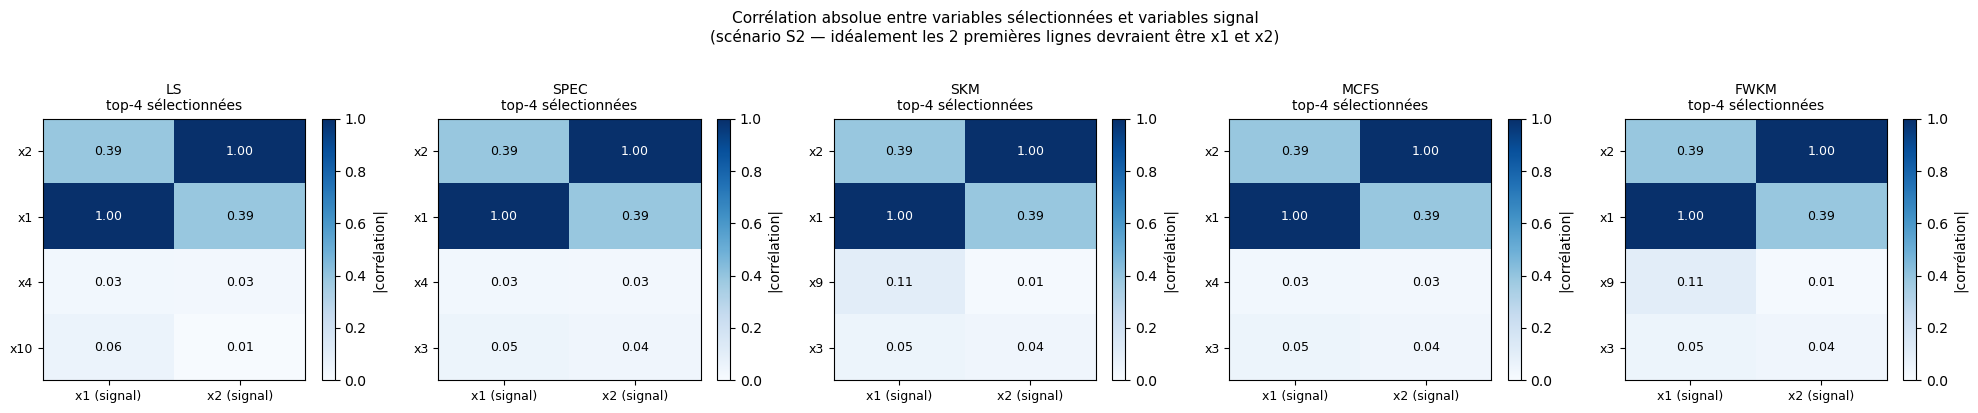

In [13]:
# ======================================================
# CORRÉLATION : variables sélectionnées vs variables signal
# Sur le scénario S2 (standard) — vérité terrain connue
# ======================================================

X_s2, y_s2 = make_synthetic(1.5, 8, 3)   # scénario S2
d_s2 = X_s2.shape[1]
feat_s2 = [f'x{i+1}' for i in range(d_s2)]
ranks_s2_all = run_all_methods(X_s2, K=3)

# Matrice de corrélation de Pearson entre toutes les variables
corr_full = np.corrcoef(X_s2.T)   # (d, d)

fig, axes = plt.subplots(1, len(METHODS), figsize=(4 * len(METHODS), 4))

for ax, m in zip(axes, METHODS):
    top_k = np.argsort(-ranks_s2_all[m])[:4]   # top-4 pour voir plus
    # Corrélation des top-k avec x1 et x2 (les vraies variables)
    corr_with_signal = np.abs(corr_full[np.ix_(top_k, [0, 1])])

    im = ax.imshow(corr_with_signal, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['x1 (signal)', 'x2 (signal)'], fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels([feat_s2[i] for i in top_k], fontsize=9)
    ax.set_title(f'{m}\ntop-4 sélectionnées', fontsize=10)
    plt.colorbar(im, ax=ax, label='|corrélation|')
    for i in range(4):
        for j in range(2):
            ax.text(j, i, f'{corr_with_signal[i, j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color='white' if corr_with_signal[i, j] > 0.6 else 'black')

plt.suptitle(
    'Corrélation absolue entre variables sélectionnées et variables signal\n'
    '(scénario S2 — idéalement les 2 premières lignes devraient être x1 et x2)',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figures/filter_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


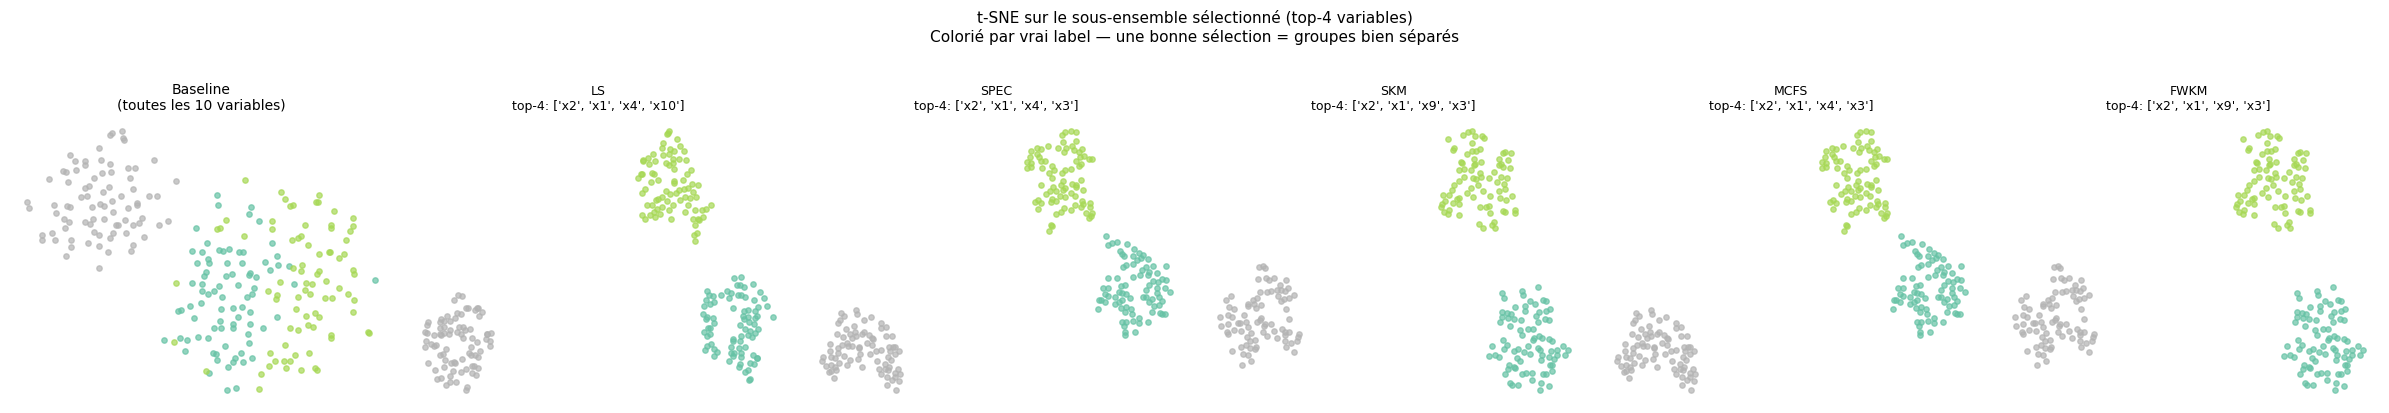

In [14]:
# ======================================================
# t-SNE : séparabilité visuelle après sélection
# ======================================================
from sklearn.manifold import TSNE

K_PRS = 4   # top-k variables retenues pour t-SNE

fig, axes = plt.subplots(1, len(METHODS) + 1,
                          figsize=(4 * (len(METHODS) + 1), 4))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Baseline : toutes les variables
emb_full = tsne.fit_transform(X_s2)
for c in range(3):
    mask = y_s2 == c
    axes[0].scatter(emb_full[mask, 0], emb_full[mask, 1],
                    s=15, alpha=0.7, color=plt.cm.Set2(c / 2))
axes[0].set_title(f'Baseline\n(toutes les {d_s2} variables)', fontsize=10)
axes[0].axis('off')

# Après sélection par chaque méthode
for ax, m in zip(axes[1:], METHODS):
    top_k = np.argsort(-ranks_s2_all[m])[:K_PRS]
    emb = tsne.fit_transform(X_s2[:, top_k])
    for c in range(3):
        mask = y_s2 == c
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   s=15, alpha=0.7, color=plt.cm.Set2(c / 2))
    sel_names = [feat_s2[i] for i in top_k]
    ax.set_title(f'{m}\ntop-{K_PRS}: {sel_names}', fontsize=9)
    ax.axis('off')

plt.suptitle(
    f't-SNE sur le sous-ensemble sélectionné (top-{K_PRS} variables)\n'
    'Colorié par vrai label — une bonne sélection = groupes bien séparés',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figures/filter_tsne.png', dpi=120, bbox_inches='tight')
plt.show()


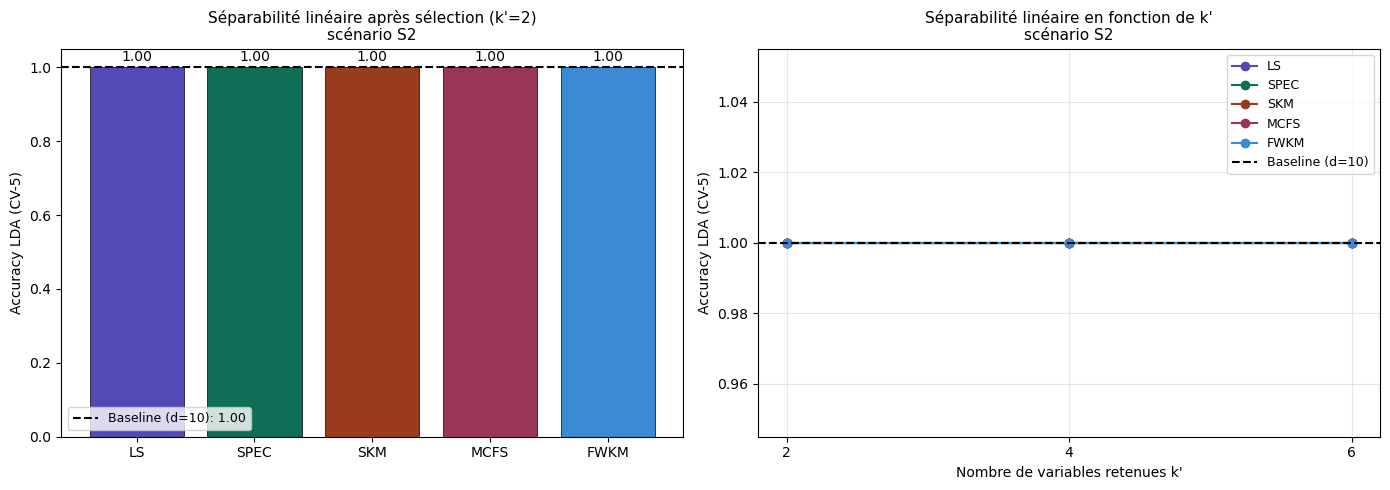

In [15]:
# ======================================================
# SCORE LDA : séparabilité linéaire après sélection
# (cross-validation 5 folds)
# ======================================================
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

lda = LinearDiscriminantAnalysis()
lda_rows = []

# Baseline
score_base = cross_val_score(lda, X_s2, y_s2, cv=5).mean()
lda_rows.append({'selection': 'Baseline (toutes)', 'LDA accuracy': score_base,
                 'k utilisé': d_s2})

for m in METHODS:
    for kp in [2, 4, 6]:
        top_k = np.argsort(-ranks_s2_all[m])[:kp]
        score = cross_val_score(lda, X_s2[:, top_k], y_s2, cv=5).mean()
        lda_rows.append({'selection': m, 'LDA accuracy': score, 'k utilisé': kp})

df_lda = pd.DataFrame(lda_rows)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : score LDA pour k'=2
sub2 = df_lda[df_lda['k utilisé'].isin([2, d_s2])].copy()
sub2_m = sub2[sub2['selection'].isin(METHODS)]
sub2_b = sub2[sub2['selection'] == 'Baseline (toutes)']

bars = axes[0].bar(sub2_m['selection'],
                   sub2_m['LDA accuracy'],
                   color=[COLORS[m] for m in METHODS],
                   edgecolor='k', linewidth=0.5)
axes[0].axhline(score_base, color='black', linestyle='--',
                 label=f'Baseline (d={d_s2}): {score_base:.2f}')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Accuracy LDA (CV-5)')
axes[0].set_title("Séparabilité linéaire après sélection (k'=2)\nscénario S2",
                   fontsize=11)
axes[0].legend(fontsize=9)
for bar, row in zip(bars, sub2_m.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{row._2:.2f}', ha='center', va='bottom', fontsize=10)

# Graphique 2 : courbe LDA(k') pour chaque méthode
for m in METHODS:
    sub_m = df_lda[df_lda['selection'] == m].sort_values('k utilisé')
    axes[1].plot(sub_m['k utilisé'], sub_m['LDA accuracy'],
                 '-o', label=m, color=COLORS[m], markersize=6)
axes[1].axhline(score_base, color='black', linestyle='--',
                 label=f'Baseline (d={d_s2})')
axes[1].set_xlabel("Nombre de variables retenues k'")
axes[1].set_ylabel('Accuracy LDA (CV-5)')
axes[1].set_title("Séparabilité linéaire en fonction de k'\nscénario S2",
                   fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([2, 4, 6])

plt.tight_layout()
plt.savefig('figures/filter_lda.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 3. Évaluation sur données réelles

### 3.1 Le Silhouette Score

Sur des données réelles, on ne connaît pas les vraies variables pertinentes. On évalue donc la **qualité du clustering produit** après sélection, via le Silhouette Score.

Pour chaque point $x_i$ appartenant au cluster $C_k$ :

$$a(i) = \frac{1}{|C_k|-1}\sum_{j \in C_k,\, j \neq i} \|x_i - x_j\| \qquad (\text{cohésion intra})$$

$$b(i) = \min_{l \neq k} \frac{1}{|C_l|}\sum_{j \in C_l} \|x_i - x_j\| \qquad (\text{séparation inter})$$

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, 1]$$

Le score global est $\bar{s} = \frac{1}{n}\sum_i s(i)$ : proche de $+1$ si les clusters sont denses et bien séparés.

### 3.2 Score de réduction

L'objectif du CEA est double : améliorer (ou maintenir) la qualité du clustering **et** réduire le nombre de variables pour des règles plus courtes. On introduit un score composite :

$$\text{Score}_{\text{CEA}}(m,\, k') = \underbrace{\text{Sil}(X_{m,k'})}_\text{qualité du clustering} - \lambda \cdot \underbrace{\frac{k'}{d}}_\text{ratio de réduction}$$

avec $\lambda = 0.3$ (paramètre à ajuster selon l'importance accordée à la réduction). La courbe $\text{Score}_{\text{CEA}}(k')$ permet de choisir le $k'$ optimal par méthode.

In [16]:
# ======================================================
# EVALUATION SUR LE DATASET RW_GLASS (PROJET CEA)
# ======================================================
import pandas as pd
import os

# 1. Chargement et préparation (selon les recommandations du document)
data_path = "Datasets/RW_glass.csv"
df_glass = pd.read_csv(data_path, encoding='utf-8-sig')

# Séparation Features / Cible (la cible 'Type' n'est pas vue par l'algo)
X_raw = df_glass.drop(columns=['Type']).values
y_glass = df_glass['Type'].values

# Standardisation (Indispensable pour FCM/K-Means selon le doc)
X_glass = StandardScaler().fit_transform(X_raw)

# Paramètres
K_GLASS = len(np.unique(y_glass)) # 6 classes
d_glass = X_glass.shape[1]        # 9 variables
LAMBDA  = 0.3

print(f"Dataset Glass : {X_glass.shape[0]} observations, {d_glass} variables, {K_GLASS} classes")

# Baseline
lbl_full = KMeans(K_GLASS, n_init=10, random_state=42).fit_predict(X_glass)
sil_full = silhouette_score(X_glass, lbl_full)
ari_full = adjusted_rand_score(y_glass, lbl_full)
print(f"Baseline (toutes les {d_glass} variables) — Silhouette : {sil_full:.3f}  |  ARI : {ari_full:.3f}")

# Rangs normalisés
ranks_glass = run_all_methods(X_glass, K=K_GLASS)

# Courbes Sil(k') et Score_CEA(k')
k_values   = list(range(2, d_glass + 1))
sil_curves = {m: [] for m in METHODS}
cea_curves = {m: [] for m in METHODS}

for m in METHODS:
    for kp in k_values:
        top = np.argsort(-ranks_glass[m])[:kp]
        lbl = KMeans(K_GLASS, n_init=5, random_state=42).fit_predict(X_glass[:, top])
        sil = silhouette_score(X_glass[:, top], lbl)
        sil_curves[m].append(sil)
        cea_curves[m].append(sil - LAMBDA * kp / d_glass)

print("Courbes calculées sur RW_glass.")

Dataset Glass : 214 observations, 9 variables, 6 classes
Baseline (toutes les 9 variables) — Silhouette : 0.318  |  ARI : 0.149


Courbes calculées sur RW_glass.


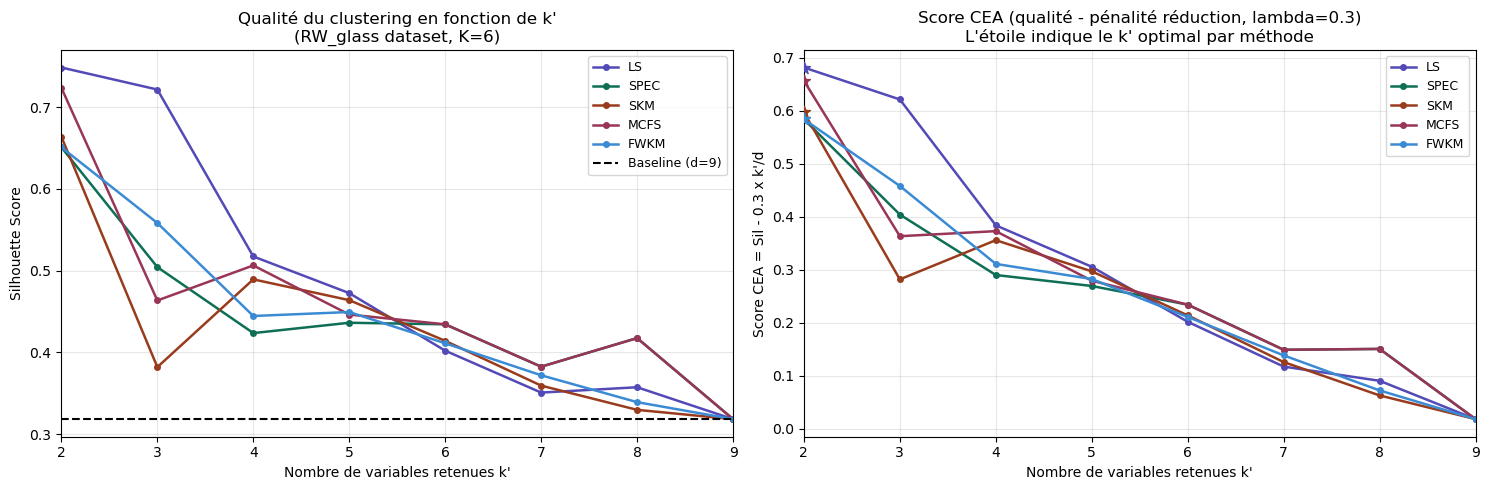


k' optimal par méthode sur RW_glass :
Méthode    k opt   Score CEA   Silhouette
------------------------------------------
LS             2       0.682        0.748
SPEC           2       0.584        0.651
SKM            2       0.597        0.664
MCFS           2       0.657        0.723
FWKM           2       0.584        0.651


In [17]:
# ======================================================
# VISUALISATION — Silhouette et Score CEA (RW_glass)
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Silhouette(k')
for m in METHODS:
    axes[0].plot(k_values, sil_curves[m], '-o', markersize=4,
                 label=m, color=COLORS[m], linewidth=1.8)
axes[0].axhline(sil_full, color='black', linestyle='--', linewidth=1.5,
                 label=f'Baseline (d={d_glass})')
axes[0].set_xlabel("Nombre de variables retenues k'")
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title(f"Qualité du clustering en fonction de k'\n(RW_glass dataset, K={K_GLASS})",
                   fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(2, d_glass)

# Score CEA(k')
for m in METHODS:
    axes[1].plot(k_values, cea_curves[m], '-o', markersize=4,
                 label=m, color=COLORS[m], linewidth=1.8)
    best_idx = np.argmax(cea_curves[m])
    axes[1].scatter([k_values[best_idx]], [cea_curves[m][best_idx]],
                    color=COLORS[m], s=80, zorder=5, marker='*')

axes[1].set_xlabel("Nombre de variables retenues k'")
axes[1].set_ylabel(f"Score CEA = Sil - {LAMBDA} x k'/d")
axes[1].set_title(
    f'Score CEA (qualité - pénalité réduction, lambda={LAMBDA})\n'
    "L'étoile indique le k' optimal par méthode",
    fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(2, d_glass)

plt.tight_layout()
plt.show()

# Tableau k' optimal
print(f"\nk' optimal par méthode sur RW_glass :")
print(f"{'Méthode':<8} {'k opt':>7} {'Score CEA':>11} {'Silhouette':>12}")
print("-" * 42)
for m in METHODS:
    bi = np.argmax(cea_curves[m])
    print(f"{m:<8} {k_values[bi]:>7d} {cea_curves[m][bi]:>11.3f} {sil_curves[m][bi]:>12.3f}")

---
## 4. Stabilité et concordance

### 4.1 Stabilité bootstrap

Une méthode peut être performante en moyenne mais **instable** — elle sélectionne $\{x_1, x_2\}$ sur un jeu de données, et $\{x_1, x_7\}$ sur le même jeu sous-échantillonné. Dans le contexte du CEA, l'instabilité est problématique car les règles floues doivent être reproductibles.

**Protocole** : on répète $B = 50$ fois un sous-échantillonnage sans remise à $80\%$, on applique la méthode et on retient le top-$k'$. La stabilité est l'**indice de Jaccard moyen** entre toutes les paires de sélections :

$$J(S_a, S_b) = \frac{|S_a \cap S_b|}{|S_a \cup S_b|} \in [0, 1]$$

$J = 1$ → mêmes variables sélectionnées à chaque bootstrap ; $J \approx 0$ → sélections très variables.

### 4.2 Concordance entre méthodes

Le **tau de Kendall** mesure si deux méthodes classent les variables dans le même ordre :

$$\tau_K = \frac{n_{\text{concordants}} - n_{\text{discordants}}}{d(d-1)/2} \in [-1, 1]$$

Une forte concordance ($\tau_K \approx 1$) entre deux méthodes signale une **redondance** : inclure les deux n'apporte pas d'information complémentaire. Une faible concordance signifie que les méthodes capturent des aspects différents de la structure.

In [18]:
# ======================================================
# STABILITE BOOTSTRAP — scenario S2 (standard)
# ======================================================

X_s2, y_s2 = make_synthetic(1.5, 8, 3)  # scenario S2


def bootstrap_stability(X, K, method, k_prime, B=50, frac=0.8, seed=0):
    """Jaccard moyen sur B sous-echantillons."""
    rng  = np.random.default_rng(seed)
    n    = X.shape[0]
    sels = []
    for _ in range(B):
        idx = rng.choice(n, size=int(n * frac), replace=False)
        try:
            rn = run_all_methods(X[idx], K)[method]
            sels.append(frozenset(np.argsort(-rn)[:k_prime]))
        except Exception:
            pass
    jacs = [len(a & b) / len(a | b)
            for i, a in enumerate(sels) for b in sels[i+1:]]
    return np.mean(jacs) if jacs else 0.0


print("Calcul stabilite bootstrap (B=50, scenario S2)...")
stability = {m: bootstrap_stability(X_s2, K=3, method=m, k_prime=2, B=50)
             for m in METHODS}
for m, v in stability.items():
    print(f"  {m:<6} : Jaccard moyen = {v:.3f}")

# Concordance tau de Kendall
ranks_s2 = run_all_methods(X_s2, K=3)
tau_mat  = np.array([
    [kendalltau(ranks_s2[m1], ranks_s2[m2]).statistic for m2 in METHODS]
    for m1 in METHODS
])

Calcul stabilite bootstrap (B=50, scenario S2)...


  LS     : Jaccard moyen = 1.000
  SPEC   : Jaccard moyen = 1.000
  SKM    : Jaccard moyen = 1.000
  MCFS   : Jaccard moyen = 0.948
  FWKM   : Jaccard moyen = 1.000


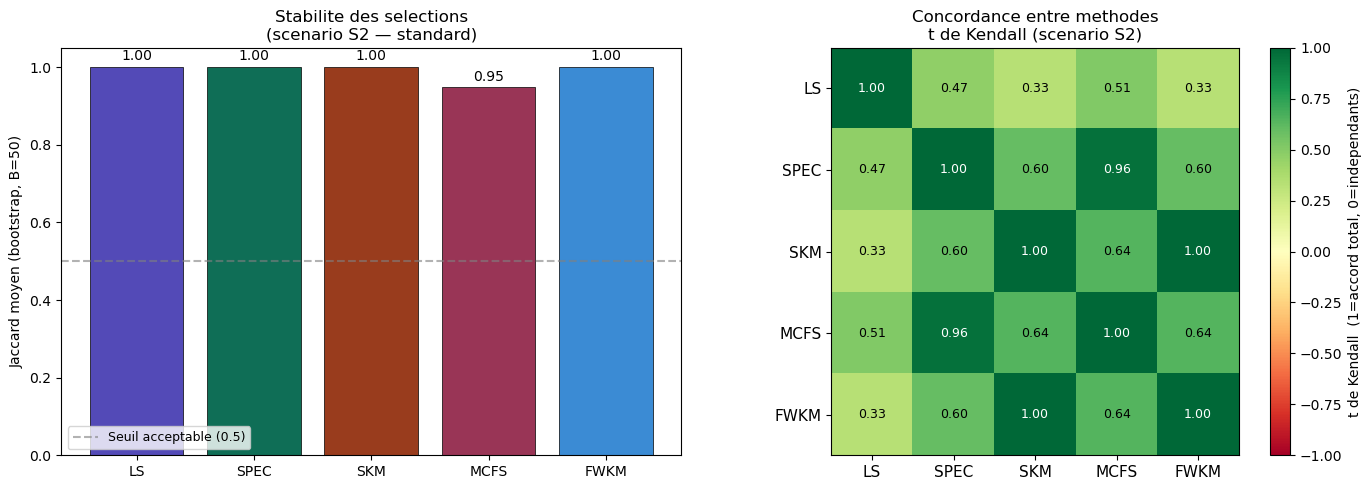

In [19]:
# ======================================================
# VISUALISATION — Stabilite et concordance
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stabilite
vals = [stability[m] for m in METHODS]
bars = axes[0].bar(METHODS, vals,
                   color=[COLORS[m] for m in METHODS],
                   edgecolor='k', linewidth=0.5)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6,
                 label='Seuil acceptable (0.5)')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Jaccard moyen (bootstrap, B=50)')
axes[0].set_title('Stabilite des selections\n(scenario S2 — standard)', fontsize=12)
axes[0].legend(fontsize=9)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=10)

# Concordance
im = axes[1].imshow(tau_mat, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(METHODS)))
axes[1].set_xticklabels(METHODS, fontsize=11)
axes[1].set_yticks(range(len(METHODS)))
axes[1].set_yticklabels(METHODS, fontsize=11)
axes[1].set_title('Concordance entre methodes\nt de Kendall (scenario S2)', fontsize=12)
plt.colorbar(im, ax=axes[1],
             label='t de Kendall  (1=accord total, 0=independants)')
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        axes[1].text(j, i, f'{tau_mat[i,j]:.2f}',
                     ha='center', va='center', fontsize=9,
                     color='white' if abs(tau_mat[i, j]) > 0.7 else 'black')

plt.tight_layout()
plt.savefig('figures/stability_concordance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Tableau de bord et synthèse

On agrège les quatre dimensions d'évaluation :

| Critère | Source | Signification |
|---------|--------|---------------|
| **ARI moyen** | Benchmarks synthétiques | Capacité à retrouver les vraies variables |
| **Stabilité** | Bootstrap Jaccard | Robustesse aux variations d'échantillon |
| **Score CEA** | Données réelles | Meilleur trade-off qualité/réduction |
| **Compat. FCM** | Famille de méthode | Adaptabilité au pipeline CEA |

In [20]:
# ======================================================
# TABLEAU DE BORD FINAL
# ======================================================


cea_best = {m: max(cea_curves[m]) for m in METHODS}
cmin, cmax = min(cea_best.values()), max(cea_best.values())
cea_norm = {m: (cea_best[m] - cmin) / (cmax - cmin + 1e-10) for m in METHODS}

dash_rows = []
for m in METHODS:
    ari_m  = df_ari[m].mean()
    stab_m = stability[m]
    cea_m  = cea_norm[m]
    gl     = (ari_m + stab_m + cea_m) / 3
    dash_rows.append({
        'Methode':          m,
        'ARI moyen':        round(ari_m,  3),
        'Stabilite':        round(stab_m, 3),
        'Score CEA (norm)': round(cea_m,  3),
        'Score global':     round(gl,     3),
    })

df_dash = (pd.DataFrame(dash_rows)
             .set_index('Methode')
             .sort_values('Score global', ascending=False))

print("=" * 65)
print("  TABLEAU DE BORD")
print("=" * 65)
print(df_dash.to_string())
print()
print(f"Methode recommandee (equilibre global) : {df_dash.index[0]}")
print(f"Priorite reproductibilite              : {df_dash['Stabilite'].idxmax()}")
print(f"Priorite compatibilite FCM             : FWKM")
print(f"Priorite performance pure              : {df_dash['ARI moyen'].idxmax()}")

  TABLEAU DE BORD
         ARI moyen  Stabilite  Score CEA (norm)  Score global
Methode                                                      
LS           0.955      1.000             1.000         0.985
MCFS         0.765      0.948             0.745         0.819
SKM          0.859      1.000             0.131         0.664
FWKM         0.955      1.000             0.000         0.652
SPEC         0.859      1.000             0.000         0.620

Methode recommandee (equilibre global) : LS
Priorite reproductibilite              : LS
Priorite compatibilite FCM             : FWKM
Priorite performance pure              : LS


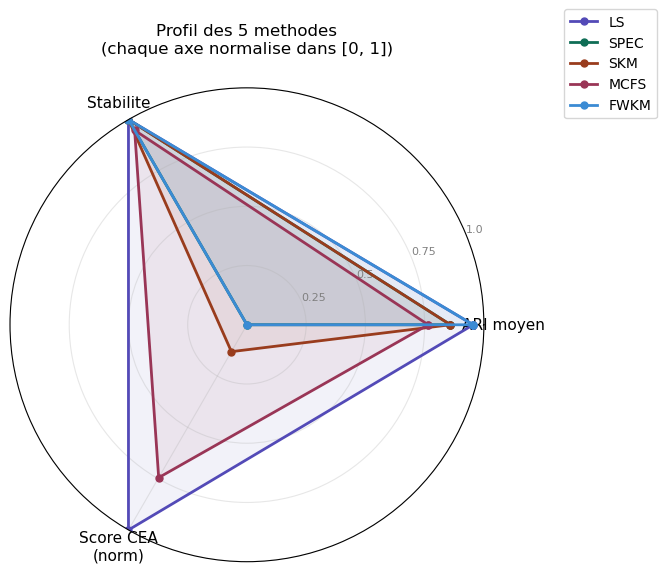

In [21]:
# ======================================================
# VISUALISATION FINALE — Radar chart
# ======================================================

categories = ['ARI moyen', 'Stabilite', 'Score CEA\n(norm)']
col_map    = ['ARI moyen', 'Stabilite', 'Score CEA (norm)']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for m in METHODS:
    row_vals = df_dash.loc[m, col_map].values.tolist() + \
               [df_dash.loc[m, col_map[0]]]
    ax.plot(angles, row_vals, '-o', label=m,
            color=COLORS[m], linewidth=2, markersize=5)
    ax.fill(angles, row_vals, alpha=0.07, color=COLORS[m])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='gray')
ax.set_title('Profil des 5 methodes\n(chaque axe normalise dans [0, 1])',
             fontsize=12, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/radar_final.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. Résumé du protocole

```
PROTOCOLE D'EVALUATION
======================

 Etape 1 — Normalisation
   Scores bruts → Rangs normalises [0, 1]
   Toutes les methodes comparables sur la meme echelle

 Etape 2 — Benchmarks synthetiques (verite terrain connue)
   6 scenarios : 3 axes (separation / bruit / nb clusters)
   Metrique : ARI post-selection (K-Means sur top-k' variables)
   → Mesure la capacite a retrouver les vraies variables

 Etape 3 — Donnees reelles (sans verite terrain)
   Metrique : Silhouette Score sur le sous-ensemble selectionne
   Score CEA = Sil(k') - lambda * k'/d
   La courbe Score CEA(k') donne le k' optimal par methode

 Etape 4 — Robustesse
   Stabilite : Jaccard bootstrap (B=50, 80% sous-echantillonnage)
   Concordance : tau de Kendall entre methodes
   → Identifie les methodes redondantes et les plus reproductibles
```

### Critères de pertinence d'une méthode

| Critère | Seuil minimal | Commentaire |
|---------|:---:|---|
| ARI moyen (synthétique) | $\geq 0.5$ | Significativement mieux que le hasard |
| Stabilité bootstrap | $\geq 0.5$ | Sélections reproductibles |
| Silhouette vs baseline | $\geq -0.05$ | Pas de dégradation significative du clustering |
| Score CEA à $k'$ optimal | $>$ baseline | La réduction vaut le coût en qualité |

### Limites

- Les scénarios synthétiques utilisent `make_blobs` (clusters gaussiens sphériques) — les méthodes spectrales peuvent être avantagées sur ce type de structure
- Le paramètre $\lambda = 0.3$ du score CEA est un choix à valider avec les experts du projet
- La compatibilité FCM est évaluée qualitativement ici — une extension directe serait de remplacer K-Means par FCM via `scikit-fuzzy`